<h1 style= 'text-align: center;'>DENGUE DATA ANALYSIS (2016 - 2020)</h1>
<hr>
<p><i>Analyst</i> <b>Johnrey Mansilungan</b></p>

In [1]:
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd
import warnings
warnings.filterwarnings('ignore')

In [2]:
df = pd.read_csv('dengue.csv')

In [3]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1020 entries, 0 to 1019
Data columns (total 5 columns):
 #   Column         Non-Null Count  Dtype 
---  ------         --------------  ----- 
 0   Month          1020 non-null   object
 1   Year           1020 non-null   int64 
 2   Region         1020 non-null   object
 3   Dengue_Cases   1020 non-null   int64 
 4   Dengue_Deaths  1020 non-null   int64 
dtypes: int64(3), object(2)
memory usage: 40.0+ KB


<h2>CHANGING DATA TYPES</h2>

In [68]:
df['Month'] = df['Month'].astype('category')  #ILL ACCESS MONTH BY NAME INSTEAD OF THE TRADITIONAL INTEGER INDEX
df['Year'] = df['Year'].astype('category')
df['Region'] = df['Region'].astype('category')
df.dtypes

Month            category
Year             category
Region           category
Dengue_Cases        int64
Dengue_Deaths       int64
Summer               bool
Winter               bool
Rainy                bool
Dry                  bool
dtype: object

<h1 style= 'text-align: center;'>Exploratory Data Analysis (EDA)</h1>

In [5]:
df

,Month,Year,Region,Dengue_Cases,Dengue_Deaths
0,January,2016,Region I,705,1
1,February,2016,Region I,374,0
2,March,2016,Region I,276,0
3,April,2016,Region I,240,2
4,May,2016,Region I,243,1
...,...,...,...,...,...
1015,August,2020,BARMM,91,0
1016,September,2020,BARMM,16,8
1017,October,2020,BARMM,13,9
1018,November,2020,BARMM,15,1


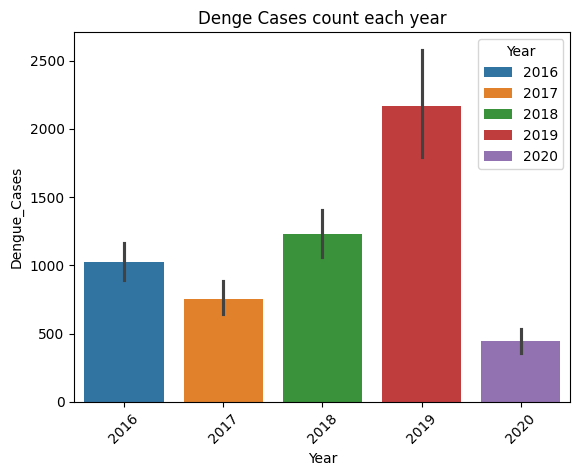

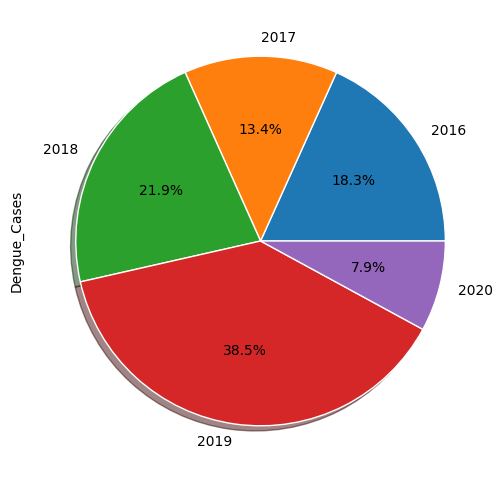

In [70]:
plt.title('Denge Cases count each year')
sns.barplot(data= df, x='Year', y='Dengue_Cases', hue='Year')
plt.xticks(rotation = 45)
plt.show()

plt.figure(figsize= (10, 6))
denguePerYear = df.groupby('Year')["Dengue_Cases"].sum()
denguePerYear.plot(kind='pie', autopct = '%1.1f%%', wedgeprops = {'edgecolor': 'white'}, shadow=True)
plt.show()

<hr>
<p>Between 2016 and 2020, <b>2019</b> recorded the most <b>dengue cases</b>, the following year was the lowest.</p>

<p style = 'text-align: right;'><b><i>INSIGHT 1</i></b></p>

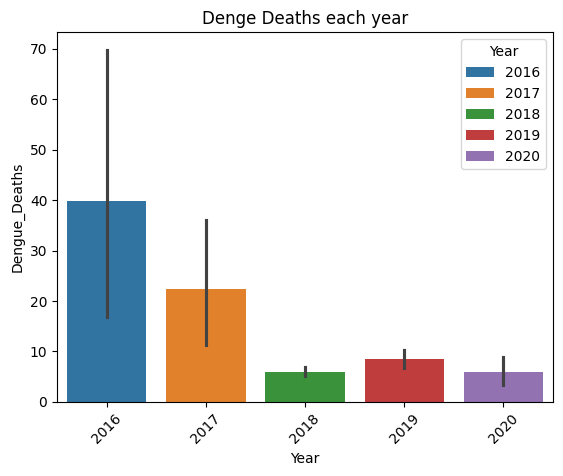

In [71]:


sns.barplot(data= df, x='Year', y='Dengue_Deaths',hue='Year')
plt.xticks(rotation = 45)
plt.title('Denge Deaths each year')
plt.show()

<hr>
<p><b>2016</b> recorded the most <b>deaths</b> among year. <b>2019</b> despite having the <b>most recorded dengue cases</b>, ranked <b>3RD</b> in the most recorded deaths. This is likely because authorities have already found ways to <b>mitigate and control cases</b>. Finding the proper vaccines could also play a crucial role in reducing deaths.</p>

<p style = 'text-align: right;'><b><i>INSIGHT 2</i></b></p>

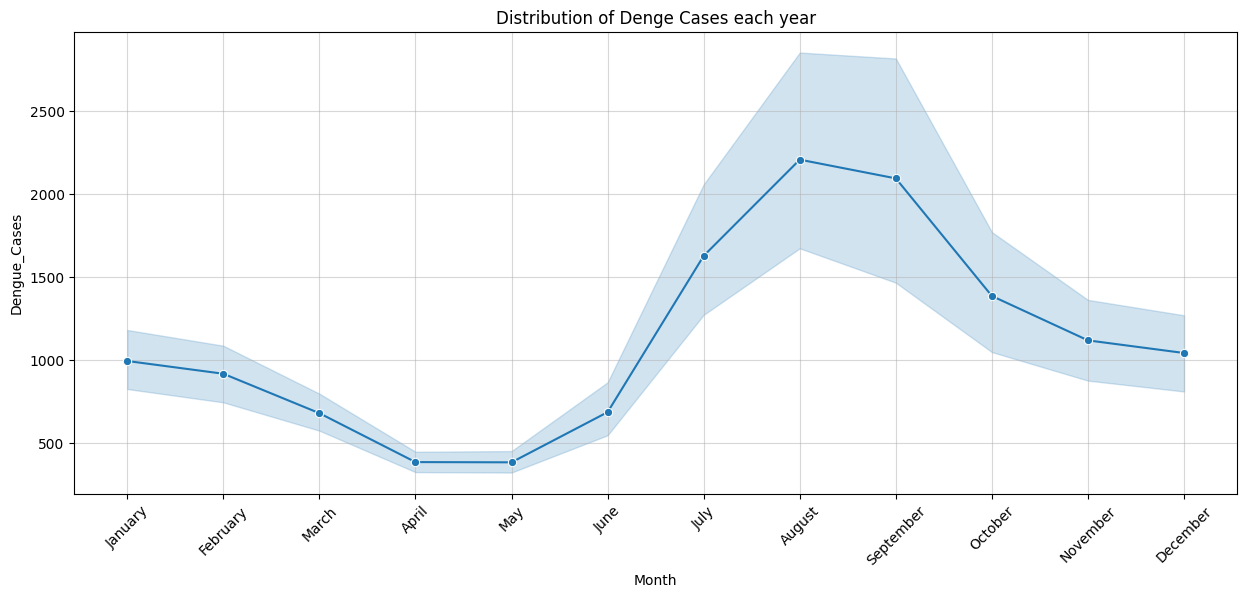

In [52]:
#casesPerMonth = df['Month'].groupby('Dengue_Cases').size()

monthOrder = ['January', 'February', 'March', 'April', 'May', 'June',
               'July', 'August', 'September', 'October', 'November', 'December']
df['Month'] = pd.Categorical(df['Month'], categories=monthOrder, ordered=True)

plt.figure(figsize = (15, 6))
sns.lineplot(data = df, x= 'Month', y = 'Dengue_Cases', marker = "o")
plt.xticks(rotation=45)
plt.grid(alpha=0.5)
plt.title('Distribution of Denge Cases each year')
plt.show()

<hr>
<p><b>Dengue</b> cases peaked in the month of <b>August</b> and had it lowest at <b>April</b> and <b>May</b>, likely because it's summer and mosquitos are not active during hot weathers.</p>

<p style = 'text-align: right;'><b><i>INSIGHT 3</i></b></p>

In [9]:
#SEPARATE AND CREATE NEW COLUMNS FOR SUMMER AND WINTER(cold season)
df['Summer'] = df['Month'].isin(['March', 'April', 'May'])
df['Winter'] = df['Month'].isin(['October', 'November', 'December'])

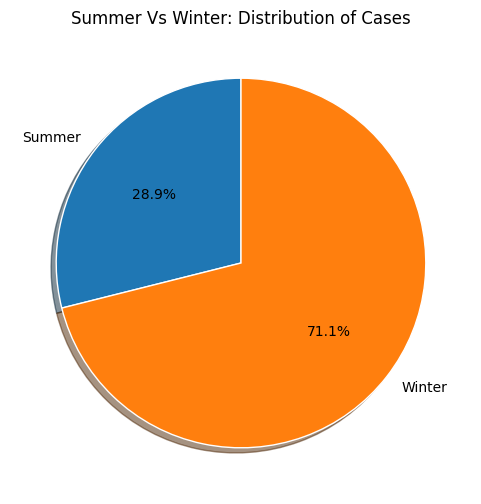

In [10]:
casesSummer = df['Dengue_Cases'][df['Summer'] == 1].sum()
casesWinter = df['Dengue_Cases'][df['Winter'] == 1].sum()

deaths = [casesSummer, casesWinter]
labels = ['Summer', 'Winter']

plt.figure(figsize = (6, 6))
plt.title('Summer Vs Winter: Distribution of Cases')
plt.pie(deaths, labels= labels,autopct='%1.1f%%', startangle=90, wedgeprops = {'edgecolor': 'white'}, shadow = True)

plt.show()

<hr>
<p><b>Cases</b> on winter season are significantly dominant compared to <b>Summer</b>, most likely because it's wet season and mosquitos are live on water for half its <b>lifetime.</b></p>

<p style = 'text-align: right;'><b><i>INSIGHT 4</i></b></p>

In [11]:
#SEPARATE AND CREATE NEW COLUMNS FOR RAINY AND DRY SEASONS
df['Rainy'] = df['Month'].isin(['June', 'July', 'August', 'September', 'October'])
df['Dry'] = df['Month'].isin(['November', 'December', 'January', 'February', 'March', 'April', 'May'])

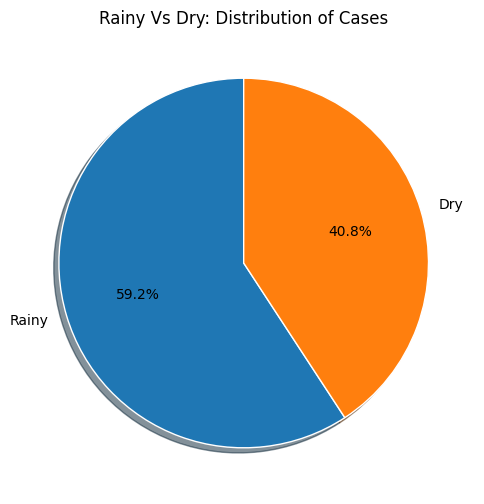

In [12]:
casesRainy = df['Dengue_Cases'][df['Rainy'] == 1].sum()
casesDry = df['Dengue_Cases'][df['Dry'] == 1].sum()

deaths = [casesRainy, casesDry]
labels = ['Rainy', 'Dry']

plt.figure(figsize = (6, 6))
plt.title('Rainy Vs Dry: Distribution of Cases')
plt.pie(deaths, labels= labels,autopct='%1.1f%%', startangle=90, wedgeprops = {'edgecolor': 'white'}, shadow = True)

plt.show()

<hr>
<p><b>Rainy</b> seasons had more cases recorded than <b>Dry</b> season because the nature of mosquitoes that cause dengue is that they live in water.</p>

<p style = 'text-align: right;'><b><i>INSIGHT 5</i></b></p>

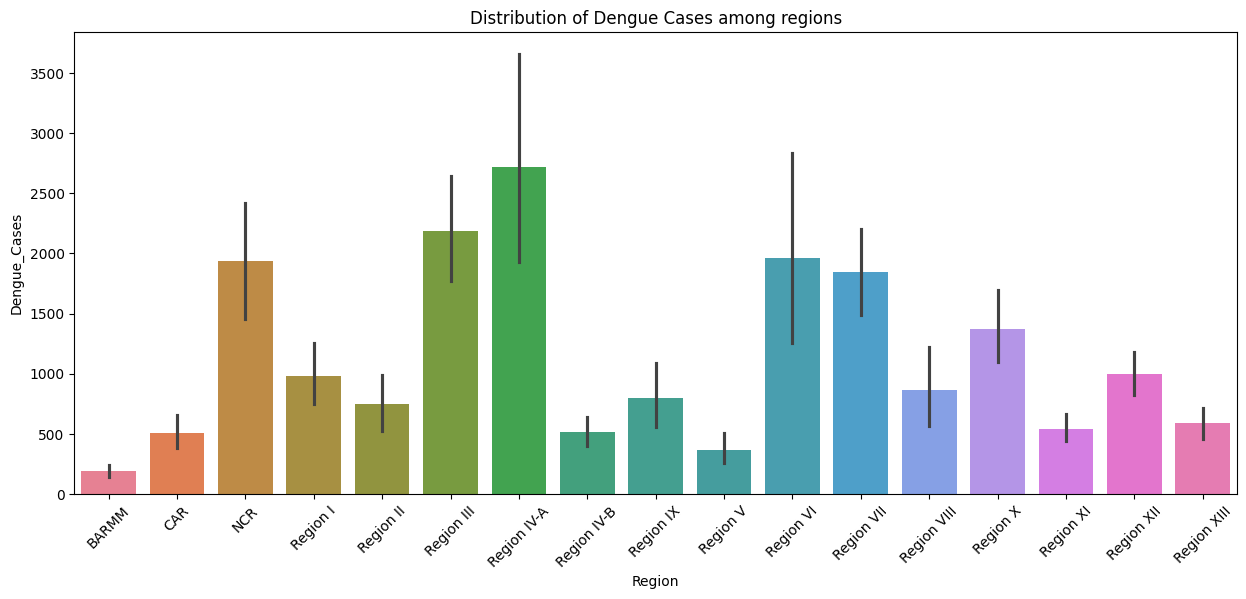

In [13]:
plt.figure(figsize = (15, 6))
sns.barplot(data = df, x= "Region", y= 'Dengue_Cases', hue='Region')
plt.xticks(rotation = 45)
plt.title('Distribution of Dengue Cases among regions')
plt.show()

<hr>
<p><b>Region IV-A</b> accounts for the largest number of Dengue Cases among regions. <b>BARMM</b> comes the lowest.</p>

<p style = 'text-align: right;'><b><i>INSIGHT 6</i></b></p>

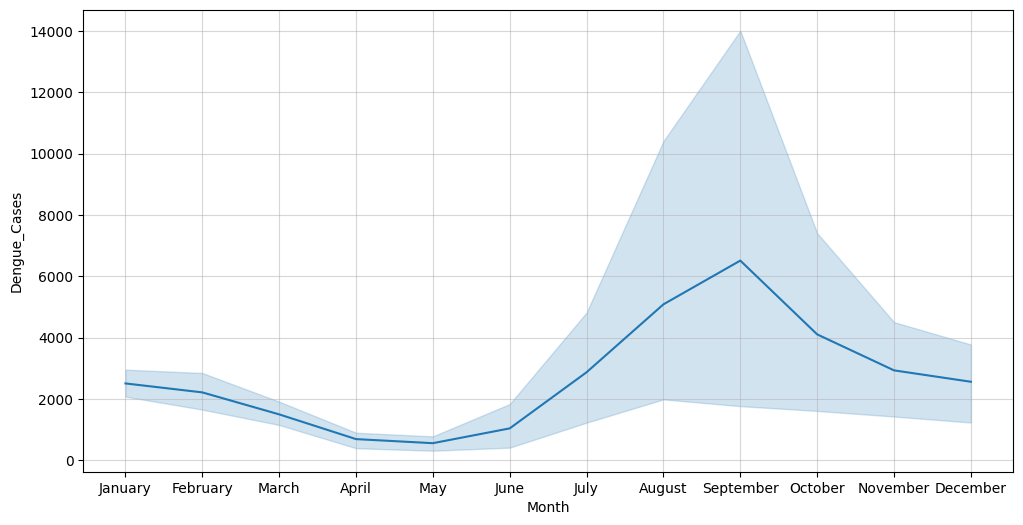

In [53]:
regionIVAdf = df[df['Region'] == 'Region IV-A']

plt.figure(figsize = (12, 6))
sns.lineplot(data= regionIVAdf, x= 'Month', y= 'Dengue_Cases')
plt.grid(alpha= 0.5)
plt.show()

<hr>
<p>Highest recorded dengue cases peaked at <b>September</b> in <b>Region IV-A</b> and had it lowest in <b>May</b> </p>

<p style = 'text-align: right;'><b><i>INSIGHT 7</i></b></p>

<Axes: ylabel='Region'>

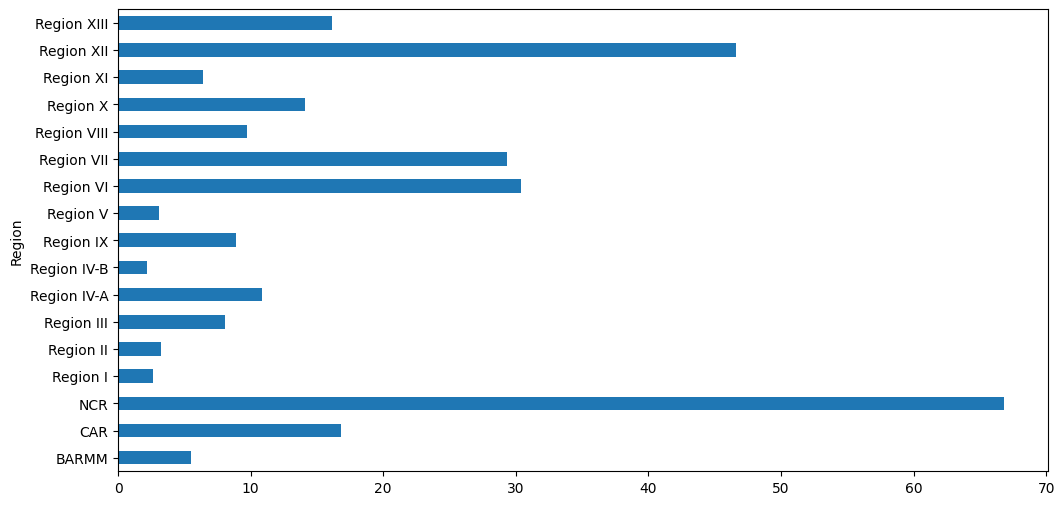

In [14]:
df.groupby('Region')['Dengue_Deaths'].mean().plot(kind='barh', figsize=(12, 6))

<hr>
<p>Despite <b>Region IV-A</b> having the most Cases, it ranked lower in terms of death counts. <b>NCR</b> had the largest number of deaths on average. This simply means that the number of dengue cases does not correlate with dengue deaths.</p>

<p style = 'text-align: right;'><b><i>INSIGHT 8</i></b></p>

In [57]:
top10largest = df.nlargest(10, 'Dengue_Deaths')
top10largest

,Month,Year,Region,Dengue_Cases,Dengue_Deaths,Summer,Winter,Rainy,Dry
849,October,2016,NCR,1033,1651,False,True,True,False
848,September,2016,NCR,1291,1291,False,False,True,False
729,October,2016,Region XII,928,1270,False,True,True,False
728,September,2016,Region XII,1083,1036,False,False,True,False
381,October,2017,Region VI,488,668,False,True,True,False
380,September,2017,Region VI,686,648,False,False,True,False
441,October,2017,Region VII,421,584,False,True,True,False
908,September,2016,CAR,538,548,False,False,True,False
440,September,2017,Region VII,2570,492,False,False,True,False
789,October,2016,Region XIII,277,481,False,True,True,False


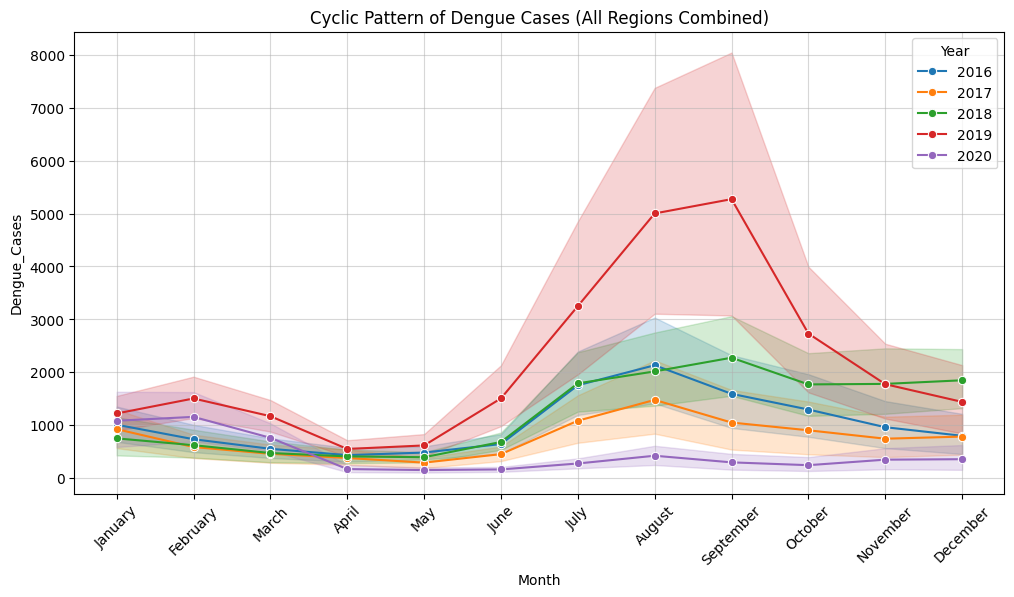

In [105]:
plt.figure(figsize=(12, 6))
sns.lineplot(data=df, x='Month', y='Dengue_Cases', hue='Year', marker='o')
plt.title('Cyclic Pattern of Dengue Cases (All Regions Combined)')
plt.xticks(rotation=45)
plt.grid(alpha=0.5)
plt.show()

<hr>
<p>Across all years, dengue cases begin to rise around <b>June</b>, peak sharply in <b>August–September</b>, and decline toward <b>December</b>. This pattern aligns closely with the <b>rainy season</b> in the </b>Philippines</b>, where stagnant water increases mosquito breeding.</p>

<p style = 'text-align: right;'><b><i>INSIGHT 9</i></b></p>

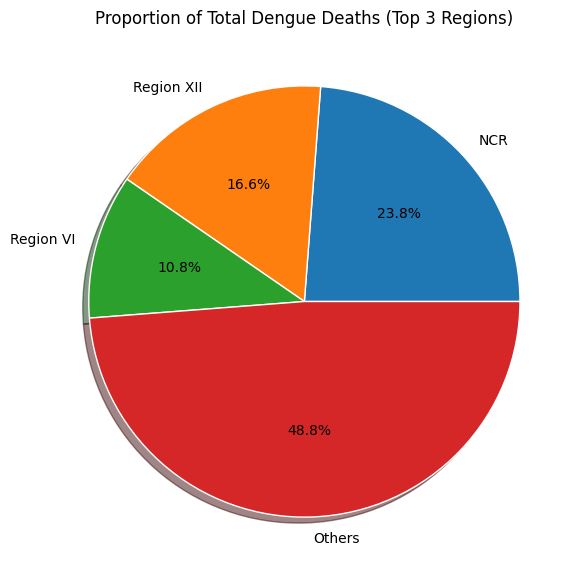

In [111]:
topRegions = df.groupby('Region')['Dengue_Deaths'].sum().nlargest(3)
others = df['Dengue_Deaths'].sum() - topRegions.sum()

values = list(topRegions) + [others]
labels = list(topRegions.index) + ['Others']

plt.figure(figsize=(7,7))
plt.pie(values, labels=labels, autopct='%1.1f%%', wedgeprops={'edgecolor': 'white'}, shadow=True)
plt.title('Proportion of Total Dengue Deaths (Top 3 Regions)')
plt.show()

<hr>
<p><b>NCR</b> accounts for the largest share of dengue deaths <b>among all regions</b>, contributing <b>23.8%</b> of the total. This suggests high population density and urban transmission factors like <i>water storage, waste buildup, and breeding grounds in residential zones</i></p>

<p style = 'text-align: right;'><b><i>INSIGHT 10</i></b></p>